# Structured Credit: CDOs and Beyond — Lecture Notebook

Companion notebook for the slide deck **"Structured Credit: CDO's and Beyond"**
(M. Haugh & G. Iyengar, *Financial Engineering & Risk Management*, Columbia University —
`notebook/test/CDO/StructuredCredit.pdf`). Every slide module is reproduced here with the
formula, the intuition, and **working Python** you can change and re-run.

## Slide map

| § | Slide module (PDF pages) | What you will be able to do in Python |
|---|---|---|
| 1 | Structured Credit: Securitization (p. 2–4) | Build a capital structure and run the loss **waterfall** through the tranches |
| 2 | The Gaussian Copula Model (p. 6–8) | Simulate $X_i = a_i M + \sqrt{1-a_i^2}\,Z_i$, set default thresholds, compute joint default probabilities with $\Phi_P$ |
| 3 | Computing the Portfolio Loss Distribution (p. 9–10) | Condition on $M$, run the **iterative procedure** (recursion) and integrate over $M$ |
| 4 | A Simple Example: Part I (p. 12–15) | The 125-bond 1-period CDO: conditional binomial and expected **equity / mezzanine / senior** losses |
| 5 | A Simple Example: Part II (p. 17–20) | Reproduce both 4-panel charts of expected tranche loss vs $\rho$ and verify every "Important Observation" |
| 6 | Mechanics of a Synthetic CDO Tranche (p. 22–24) | Tranche loss function $\text{TL}^{L,U}_t(l)$ with notional and recovery, and expected tranche loss over time |
| 7 | Fair Value of a CDO Tranche (p. 26–28) | Premium leg, default leg, **fair spread** $S^*$, upfront quotes, **implied correlation** (and when it fails) |
| 8 | Cash and Synthetic CDOs (p. 30–32) | Hedge a synthetic tranche with the index/CDS: **credit deltas** and leverage |
| 9 | Pricing & Risk Management of CDO Portfolios (p. 34–36) | Mark the sample portfolio to model, Greeks (CS01, Corr01), **scenario analysis**, the May 2005 correlation shock |
| 10 | A Brief Aside on Copulas (p. 37–38) | Bivariate Normal vs **Meta-Gumbel** with the same correlation; why the copula changes tranche prices |
| 11 | CDO-Squared's and Beyond (p. 40–45) | Build a **CDO²** from mezzanine tranches with overlapping collateral and see the cliff risk |
| 12 | Summary + link to Problem Set 4 | Formula cheat-sheet; the problem set is the $a_i = 0$ special case of §3 |

> **Notation follows the slides.** $N$ credits, notional $A_i$, recovery $R_i$, risk-neutral
> default probability by time $t$ $q_i(t)$, common factor $M$, factor loading $a_i$ (or $\sqrt{\rho}$ in the
> homogeneous example), number of defaults $l$, loss distribution $p^N(l,t)$, tranche attachment
> points $L < U$, tranche loss $\text{TL}^{L,U}_t$.

In [1]:
# pip install numpy pandas scipy matplotlib
import math
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, multivariate_normal, kendalltau
from scipy.optimize import brentq
from scipy.special import gammaln, xlogy, xlog1py

pd.options.display.float_format = "{:,.4f}".format
rng = np.random.default_rng(2026)

# Chart style: one categorical order used everywhere (Equity, Mezzanine, Senior, extra)
COL = {"equity": "#2a78d6", "mezz": "#eb6834", "senior": "#1baf7a", "extra": "#4a3aa7", "ink": "#52514e"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#2b2b29", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "lines.linewidth": 2, "legend.frameon": False,
})
print("Ready.")

Ready.


---
## 1. Securitization and the CDO capital structure (slides p. 2–4)

**Securitization** builds *new* securities from the cash flows of a pool of underlying securities.
The point is to create securities with a **broad range of risk profiles**, so that investors who
would never buy the underlying bonds still want a piece. Higher demand for the underlying cash
flows lowers the cost of capital for the original issuers.

* **CDO** (collateralized debt obligation): the pool is fixed-income securities (bonds).
* **CLO** (collateralized loan obligation): the pool is loans.
* The first CDOs (mid-1990s) were driven by **regulatory arbitrage** (see §8).

The slide diagram (p. 3): **125 bonds** form the collateral; the CDO splits their losses into
**tranches** — Equity $0\%$–$3\%$, Mezzanine $3\%$–$7\%$, …, Senior $40\%$–$100\%$.

### The waterfall

Losses hit the **bottom** of the capital structure first. A tranche $[L, U]$ (in % of portfolio
notional) only starts to lose once total portfolio loss exceeds its **attachment point** $L$, and is
wiped out at its **detachment point** $U$:

$$
\text{Tranche loss}(\ell) = \max\big(\min(\ell, U) - L,\; 0\big) = (\ell - L)^+ - (\ell - U)^+ ,
$$

where $\ell$ is the total portfolio loss. This is a **call spread** on the portfolio loss. Because the
tranches are contiguous and cover $[0, 100\%]$, the tranche losses always **add back up** to $\ell$.

In [2]:
def tranche_loss(loss, L, U):
    # Loss absorbed by tranche [L, U] for a portfolio loss `loss` (same units as L, U). Vectorised.
    return np.maximum(np.minimum(loss, U) - L, 0.0)

# The slide's capital structure, with the "..." filled in by the standard CDX IG tranches
cap_structure = pd.DataFrame({
    "tranche": ["Equity", "Mezzanine", "Senior", "Senior 2", "Super-senior 1", "Super-senior 2"],
    "L": [0.00, 0.03, 0.07, 0.10, 0.15, 0.30],
    "U": [0.03, 0.07, 0.10, 0.15, 0.30, 1.00],
})
cap_structure["size"] = cap_structure.U - cap_structure.L
assert np.isclose(cap_structure["size"].sum(), 1.0)

def waterfall(portfolio_loss, cs=cap_structure):
    out = cs.copy()
    out["tranche loss (% of portfolio)"] = tranche_loss(portfolio_loss, out.L, out.U)
    out["tranche loss (% of tranche)"] = out["tranche loss (% of portfolio)"] / out["size"]
    return out

wf = waterfall(0.05)          # a 5% portfolio loss
print("Portfolio loss = 5%")
display(wf.style.format({c: "{:.2%}" for c in wf.columns if c != "tranche"}).hide(axis="index"))
print(f"Sum of tranche losses = {wf['tranche loss (% of portfolio)'].sum():.2%}  (always = portfolio loss)")

Portfolio loss = 5%


tranche,L,U,size,tranche loss (% of portfolio),tranche loss (% of tranche)
Equity,0.00%,3.00%,3.00%,3.00%,100.00%
Mezzanine,3.00%,7.00%,4.00%,2.00%,50.00%
Senior,7.00%,10.00%,3.00%,0.00%,0.00%
Senior 2,10.00%,15.00%,5.00%,0.00%,0.00%
Super-senior 1,15.00%,30.00%,15.00%,0.00%,0.00%
Super-senior 2,30.00%,100.00%,70.00%,0.00%,0.00%


Sum of tranche losses = 5.00%  (always = portfolio loss)


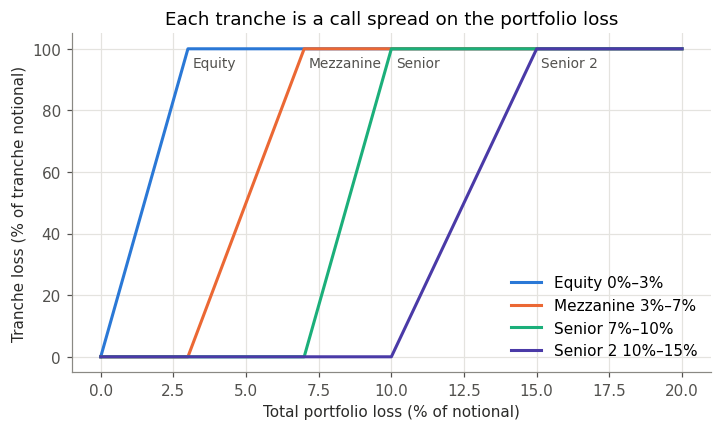

In [3]:
ell = np.linspace(0, 0.20, 401)
fig, ax = plt.subplots(figsize=(7.5, 4))
for (name, L, U), c in zip(cap_structure[["tranche", "L", "U"]].values[:4],
                           [COL["equity"], COL["mezz"], COL["senior"], COL["extra"]]):
    y = tranche_loss(ell, L, U) / (U - L)
    ax.plot(ell * 100, y * 100, color=c, label=f"{name} {L:.0%}–{U:.0%}")
    ax.annotate(name, (U * 100, 100), xytext=(3, -12), textcoords="offset points", color=COL["ink"], fontsize=9)
ax.set(xlabel="Total portfolio loss (% of notional)", ylabel="Tranche loss (% of tranche notional)",
       title="Each tranche is a call spread on the portfolio loss")
ax.legend(loc="lower right")
plt.show()

**Reading the chart.** The equity tranche is thin ($3\%$), so a few percent of portfolio losses wipe
it out — it is **highly levered** to portfolio losses. Senior tranches only lose in extreme scenarios,
which is why they were rated AAA. *Who* is exposed depends entirely on **how likely large joint
losses are** — and that is a question about **default correlation**, which is what the Gaussian
copula model (next) is for.

The mechanics of a CDO are very close to those of a **credit default swap (CDS)**: the tranche
protection seller is paid a running premium and pays out realized losses (§6–7).

---
## 2. The Gaussian copula model (slides p. 6–8)

### Assumptions (p. 6)

* $N$ credits; credit $i$ has notional $A_i$ and recovery rate $R_i$, so its default costs
  $A_i(1-R_i)$. $R_i$ is usually taken as fixed and known (in reality it is random).
* The risk-neutral distribution of each default time is known (bootstrapped from **CDS spreads** or
  **bond prices**), so we know $q_i(t) = \mathbb{Q}(\tau_i \le t)$ for every $t$.

### The one-factor model (p. 7)

Let $X_i$ be the **normalized asset value** of firm $i$:

$$
X_i = a_i M + \sqrt{1 - a_i^2}\, Z_i , \qquad M, Z_1, \dots, Z_N \overset{\text{iid}}{\sim} N(0,1),\quad a_i \in [0,1].
$$

Each $X_i \sim N(0,1)$ and

$$
\operatorname{Corr}(X_i, X_j) = a_i a_j \quad (i \ne j).
$$

### Default rule (p. 8)

Credit $i$ has defaulted by $t_i$ if $X_i$ falls below a threshold $\bar{x}_i(t_i)$. To match the
marginal default probability we need $\mathbb{Q}(X_i \le \bar{x}_i) = q_i(t_i)$, so

$$
\bar{x}_i(t_i) = \Phi^{-1}\big(q_i(t_i)\big).
$$

The **joint** distribution of default times is then the Gaussian copula:

$$
F(t_1,\dots,t_N) = \Phi_P\big(\Phi^{-1}(q_1(t_1)), \dots, \Phi^{-1}(q_N(t_N))\big), \qquad P_{ij} = a_i a_j ,
$$

where $\Phi_P$ is the multivariate normal CDF with correlation matrix $P$. It is a **1-factor** model
because a single variable $M$ (think: "the economy") drives all the dependence.

In [4]:
def simulate_assets(a, n_sims, rng):
    # X_i = a_i M + sqrt(1-a_i^2) Z_i  -> array (n_sims, N)
    a = np.asarray(a, float)
    M = rng.standard_normal((n_sims, 1))
    Z = rng.standard_normal((n_sims, a.size))
    return a * M + np.sqrt(1 - a**2) * Z

a_demo = np.array([0.3, 0.5, 0.7, 0.9])
q_demo = np.array([0.02, 0.05, 0.10, 0.03])
X = simulate_assets(a_demo, 400_000, rng)

print("Empirical vs model correlation  Corr(X_i, X_j) = a_i a_j")
emp = np.corrcoef(X.T)
rows = [(i + 1, j + 1, emp[i, j], a_demo[i] * a_demo[j]) for i, j in combinations(range(4), 2)]
display(pd.DataFrame(rows, columns=["i", "j", "empirical", "a_i a_j"]).style.format(precision=4).hide(axis="index"))

xbar = norm.ppf(q_demo)                       # default thresholds
D = X <= xbar                                  # default indicators
print("Marginal default probabilities reproduced:")
print(pd.DataFrame({"q_i (input)": q_demo, "x̄_i = Φ⁻¹(q_i)": xbar, "simulated": D.mean(0)}).round(4).to_string())

Empirical vs model correlation  Corr(X_i, X_j) = a_i a_j


i,j,empirical,a_i a_j
1,2,0.1493,0.1500
1,3,0.2108,0.2100
1,4,0.2719,0.2700
2,3,0.3499,0.3500
2,4,0.4498,0.4500
3,4,0.6300,0.6300


Marginal default probabilities reproduced:
   q_i (input)  x̄_i = Φ⁻¹(q_i)  simulated
0       0.0200          -2.0537     0.0199
1       0.0500          -1.6449     0.0503
2       0.1000          -1.2816     0.0996
3       0.0300          -1.8808     0.0297


### Joint defaults and default correlation

For two credits the copula formula gives the **joint default probability** directly:

$$
\mathbb{Q}(\tau_i \le t,\ \tau_j \le t) = \Phi_2\big(\bar{x}_i, \bar{x}_j;\ a_i a_j\big),
$$

and the **default correlation** (correlation of the default indicators $D_i, D_j$) is

$$
\rho^{D}_{ij} = \frac{\Phi_2(\bar{x}_i,\bar{x}_j; a_i a_j) - q_i q_j}{\sqrt{q_i(1-q_i)\,q_j(1-q_j)}} .
$$

Default correlation is **much smaller** than asset correlation: defaults are rare events, so even
strongly correlated assets rarely default together.

Φ_P joint default prob (credits 2,3) = 0.01384   simulated = 0.01412   independent would be 0.00500


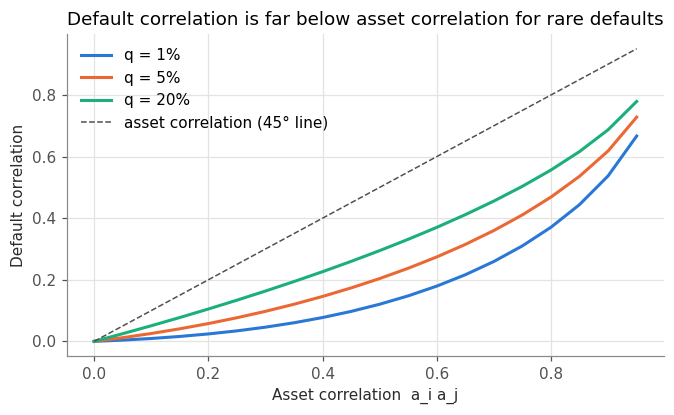

In [5]:
def joint_default_prob(qi, qj, rho_ij):
    xi, xj = norm.ppf(qi), norm.ppf(qj)
    return multivariate_normal(mean=[0, 0], cov=[[1, rho_ij], [rho_ij, 1]]).cdf([xi, xj])

def default_correlation(qi, qj, rho_ij):
    pij = joint_default_prob(qi, qj, rho_ij)
    return (pij - qi * qj) / math.sqrt(qi * (1 - qi) * qj * (1 - qj))

i, j = 1, 2                                    # credits 2 and 3 (a = 0.5, 0.7)
pij = joint_default_prob(q_demo[i], q_demo[j], a_demo[i] * a_demo[j])
print(f"Φ_P joint default prob (credits {i+1},{j+1}) = {pij:.5f}   simulated = {(D[:, i] & D[:, j]).mean():.5f}"
      f"   independent would be {q_demo[i]*q_demo[j]:.5f}")

rhos = np.linspace(0, 0.95, 20)
fig, ax = plt.subplots(figsize=(7, 3.8))
for q, c in zip([0.01, 0.05, 0.20], [COL["equity"], COL["mezz"], COL["senior"]]):
    ax.plot(rhos, [default_correlation(q, q, r) for r in rhos], color=c, label=f"q = {q:.0%}")
ax.plot(rhos, rhos, color=COL["ink"], lw=1, ls="--", label="asset correlation (45° line)")
ax.set(xlabel="Asset correlation  a_i a_j", ylabel="Default correlation",
       title="Default correlation is far below asset correlation for rare defaults")
ax.legend()
plt.show()

---
## 3. Computing the portfolio loss distribution (slides p. 9–10)

To price CDO tranches we need $p^N(l,t)$ = risk-neutral probability of **exactly $l$ defaults** by $t$.

**Key idea: condition on $M$.** Given $M$, the $Z_i$ are independent, so the $N$ default events are
**conditionally independent** with probabilities

$$
q_i(t \mid M) = \mathbb{Q}\big(X_i \le \bar{x}_i(t) \mid M\big)
= \Phi\!\left(\frac{\bar{x}_i(t) - a_i M}{\sqrt{1-a_i^2}}\right).
$$

Then integrate the conditional distribution against the density of $M$:

$$
p^N(l,t) = \int_{-\infty}^{\infty} p^N(l,t \mid M)\, \phi(M)\, dM . \tag{2}
$$

### The iterative procedure (p. 10)

*(The formula on this slide is missing from the PDF export — it is reconstructed here.)*
Let $p^k(l,t\mid M)$ be the probability of $l$ defaults among the **first $k$** credits. Start with
$p^0(0,t\mid M) = 1$ and add one credit at a time:

$$
p^{k+1}(l,t\mid M) = p^{k}(l,t\mid M)\,\big(1 - q_{k+1}(t\mid M)\big) + p^{k}(l-1,t\mid M)\, q_{k+1}(t\mid M),
\qquad l = 0,\dots,k+1 ,
$$

with $p^k(-1,\cdot) = 0$. After $N$ steps we have $p^N(l,t\mid M)$; a **numerical integration** of (2)
over $M$ gives $p^N(l,t)$. This handles **different** $q_i$ and $a_i$ for every credit.

If all notionals $A_i = A$ and recoveries $R_i = R$ are equal, every default costs $A(1-R)$, so the
distribution of the **number** of defaults *is* the distribution of the **portfolio loss**.

**Numerical integration.** We integrate on a fine grid $M \in [-8, 8]$ (the normal density is
$< 10^{-14}$ beyond that), weighting each node by $\phi(M)\,\Delta M$.

In [6]:
M_GRID = np.linspace(-8, 8, 801)
M_W = norm.pdf(M_GRID) * (M_GRID[1] - M_GRID[0])
M_W /= M_W.sum()                                  # weights sum to 1

def cond_default_prob(q, a, M):
    # q_i(t|M) for every credit (rows) and every M node (cols)
    q, a = np.atleast_1d(q).astype(float), np.atleast_1d(a).astype(float)
    a = np.broadcast_to(a, q.shape)
    return norm.cdf((norm.ppf(q)[:, None] - a[:, None] * M[None, :]) / np.sqrt(1 - a[:, None] ** 2))

def recursion(qs):
    # Iterative procedure. qs: (N,) or (N, nM) default probs -> p^N(l | .) with shape (N+1,) or (N+1, nM)
    qs = np.asarray(qs, float)
    N = qs.shape[0]
    P = np.zeros((N + 1,) + qs.shape[1:])
    P[0] = 1.0
    for k in range(N):
        qk = qs[k]
        P[1:k + 2] = P[1:k + 2] * (1 - qk) + P[0:k + 1] * qk   # uses old values on the right
        P[0] = P[0] * (1 - qk)
    return P

def loss_distribution(q, a, M=M_GRID, W=M_W):
    # Unconditional p^N(l) for heterogeneous q_i, a_i under the 1-factor Gaussian copula.
    q, a = np.atleast_1d(q).astype(float), np.broadcast_to(np.atleast_1d(a).astype(float), np.shape(q))
    if np.all(a == 0):                               # independent: no integral needed
        return recursion(q)
    return recursion(cond_default_prob(q, a, M)) @ W

**Check the recursion three ways** on a small heterogeneous portfolio:

1. probabilities sum to 1 and $\mathbb{E}[\#\text{defaults}] = \sum_i q_i$ (true for *any* correlation);
2. compare with a direct Monte Carlo simulation of the copula;
3. compare with a brute-force enumeration of all $2^N$ default scenarios *conditional on $M$*.

In [7]:
N_h = 10
q_h = np.array([0.01, 0.02, 0.03, 0.05, 0.08, 0.02, 0.04, 0.10, 0.06, 0.03])
a_h = np.array([0.2, 0.3, 0.5, 0.4, 0.6, 0.3, 0.5, 0.7, 0.4, 0.5])

p_semi = loss_distribution(q_h, a_h)
print(f"sum = {p_semi.sum():.12f}   E[l] = {np.arange(N_h+1) @ p_semi:.6f}   sum q_i = {q_h.sum():.6f}")

# (2) Monte Carlo
Xs = simulate_assets(a_h, 1_000_000, rng)
n_def = (Xs <= norm.ppf(q_h)).sum(1)
p_mc = np.bincount(n_def, minlength=N_h + 1) / n_def.size

# (3) brute force conditional on M, then integrate
bits = (np.arange(2**N_h)[:, None] >> np.arange(N_h)) & 1
qM = cond_default_prob(q_h, a_h, M_GRID)                     # (N, nM)
logp = bits @ np.log(qM) + (1 - bits) @ np.log1p(-qM)          # (2^N, nM)
p_brute = np.array([np.exp(logp[bits.sum(1) == l]).sum(0) @ M_W for l in range(N_h + 1)])

cmp = pd.DataFrame({"l": range(N_h + 1), "recursion + integral": p_semi, "brute force": p_brute, "Monte Carlo": p_mc})
display(cmp.head(7).style.format(precision=6).hide(axis="index"))
assert np.allclose(p_semi, p_brute, atol=1e-12)

sum = 1.000000000000   E[l] = 0.440000   sum q_i = 0.440000


l,recursion + integral,brute force,Monte Carlo
0,0.698614,0.698614,0.697788
1,0.205333,0.205333,0.206034
2,0.065475,0.065475,0.065539
3,0.021550,0.021550,0.021574
4,0.006680,0.006680,0.006627
5,0.001837,0.001837,0.001868
6,0.000424,0.000424,0.000464


---
## 4. A simple example: a 1-period CDO — Part I (slides p. 12–15)

*(From Donnelly & Embrechts, "The Devil is in the Tails", ASTIN Bulletin 40(1), 2010.)*

* Maturity **1 year**; **125 bonds**; each pays **1 unit** after one year if it has not defaulted.
* Recovery rate **zero**, so each default loses exactly 1 unit.
* Three tranches (slide p. 12): **Equity** = defaults 1–3, **Mezzanine** = defaults 4–6,
  **Senior** = defaults 7–9. Each has a notional of **3 units**.

### Homogeneous Gaussian copula (p. 13)

Every bond has the same default probability $q$ and every pair the same correlation $\rho$:

$$
X_i = \sqrt{\rho}\,M + \sqrt{1-\rho}\,Z_i , \qquad \bar{x}_1 = \dots = \bar{x}_N = \Phi^{-1}(q).
$$

$$
\mathbb{Q}(\text{bond } i \text{ defaults} \mid M) = \mathbb{Q}\!\left(Z_i \le \frac{\Phi^{-1}(q) - \sqrt{\rho}M}{\sqrt{1-\rho}}\,\Big|\, M\right)
= \Phi\!\left(\frac{\Phi^{-1}(q) - \sqrt{\rho}M}{\sqrt{1-\rho}}\right) =: q_M .
$$

### The conditional default distribution (p. 14)

Conditional on $M$ the defaults are independent with the **same** probability $q_M$, so the number of
defaults is **binomial**:

$$
p^N(l \mid M) = \binom{N}{l} q_M^{\,l} (1-q_M)^{N-l}. \tag{4}
$$

> **Slide question: why is (4) no longer valid when correlations and default probabilities are not
> identical?** Because then $q_i(t\mid M)$ differs across credits, and a sum of independent Bernoulli
> variables with **different** success probabilities is *not* binomial (it is Poisson-binomial).
>
> **Slide question: how do we calculate $p^N(l\mid M)$ in that case?** With the **iterative procedure**
> of §3, adding one credit at a time. (Both routes give identical answers in the homogeneous case — checked below.)

In [8]:
def binom_pmf(l, N, p):
    # Binomial pmf in log space; exact at p = 0 or 1 (which happens for rho near 1).
    log_c = gammaln(N + 1) - gammaln(l + 1) - gammaln(N - l + 1)
    return np.exp(log_c + xlogy(l, p) + xlog1py(N - l, -p))

def loss_distribution_homog(N, q, rho, M=M_GRID, W=M_W):
    # p^N(l) for the homogeneous model via the conditional binomial (4) and the integral (5).
    l = np.arange(N + 1)
    if rho == 0:
        return binom_pmf(l, N, q)
    qM = norm.cdf((norm.ppf(q) - math.sqrt(rho) * M) / math.sqrt(1 - rho))
    return binom_pmf(l[:, None], N, qM[None, :]) @ W

N, q, rho = 125, 0.02, 0.3
p_bin = loss_distribution_homog(N, q, rho)
p_rec = loss_distribution(np.full(N, q), np.full(N, math.sqrt(rho)))
print(f"max |binomial route - recursion route| = {np.abs(p_bin - p_rec).max():.2e}")

max |binomial route - recursion route| = 7.94e-15


### Expected tranche losses (p. 15)

With 3-unit tranches:

$$
\begin{aligned}
\mathbb{E}^{\mathbb{Q}}_0[\text{Equity loss}] &= 3\,\mathbb{P}(l \ge 3) + \sum_{k=1}^{2} k\,\mathbb{P}(l = k), \\
\mathbb{E}^{\mathbb{Q}}_0[\text{Mezzanine loss}] &= 3\,\mathbb{P}(l \ge 6) + \sum_{k=1}^{2} k\,\mathbb{P}(l = k+3), \\
\mathbb{E}^{\mathbb{Q}}_0[\text{Senior loss}] &= 3\,\mathbb{P}(l \ge 9) + \sum_{k=1}^{2} k\,\mathbb{P}(l = k+6),
\end{aligned}
$$

with each probability obtained by integrating the binomial against $\phi$:

$$
p(l) = \int_{-\infty}^{\infty} p^N(l \mid M)\,\phi(M)\,dM. \tag{5}
$$

These are all special cases of one formula, $\mathbb{E}[\text{TL}] = \sum_l \max(\min(l,U)-L,0)\,p(l)$,
with $(L,U) = (0,3), (3,6), (6,9)$ in units of defaults.

In [9]:
def expected_tranche_loss_units(p, L, U):
    l = np.arange(len(p))
    return tranche_loss(l, L, U) @ p

def slide_formula(p, start):          # 3 P(l >= start+3) + sum_{k=1}^{2} k P(l = start + k)
    return 3 * p[start + 3:].sum() + sum(k * p[start + k] for k in (1, 2))

TRANCHES_I = {"Equity": (0, 3), "Mezzanine": (3, 6), "Senior": (6, 9)}

rows = []
for q in [0.01, 0.02, 0.03, 0.04]:
    for rho in [0.0, 0.2, 0.5, 0.9]:
        p = loss_distribution_homog(125, q, rho)
        r = {"q": q, "rho": rho}
        for name, (L, U) in TRANCHES_I.items():
            r[name] = expected_tranche_loss_units(p, L, U)
            assert np.isclose(r[name], slide_formula(p, L))   # slide p.15 formula
        rows.append(r)
part1 = pd.DataFrame(rows)
display(part1.style.format({"q": "{:.0%}", "rho": "{:.1f}", "Equity": "{:.3f}", "Mezzanine": "{:.3f}", "Senior": "{:.3f}"})
        .hide(axis="index"))

q,rho,Equity,Mezzanine,Senior
1%,0.0,1.202,0.048,0.000
1%,0.2,0.902,0.216,0.075
1%,0.5,0.526,0.218,0.131
1%,0.9,0.141,0.097,0.080
2%,0.0,2.093,0.388,0.018
2%,0.2,1.443,0.544,0.245
2%,0.5,0.844,0.420,0.276
2%,0.9,0.247,0.178,0.150
3%,0.0,2.597,1.015,0.132
3%,0.2,1.810,0.864,0.453


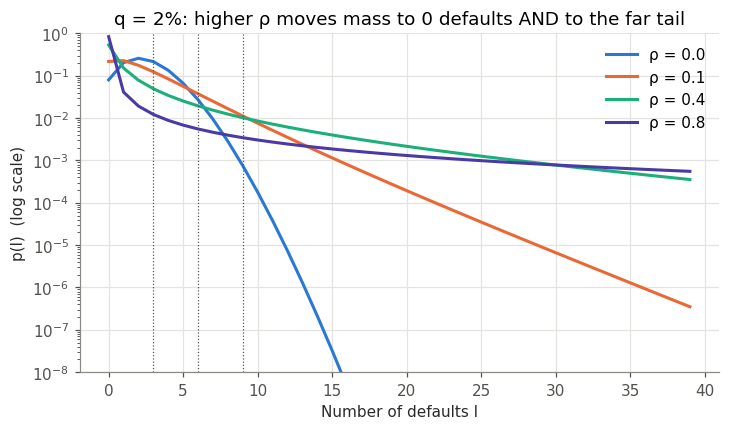

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
l = np.arange(126)
for rho, c in zip([0.0, 0.1, 0.4, 0.8], [COL["equity"], COL["mezz"], COL["senior"], COL["extra"]]):
    ax.semilogy(l[:40], loss_distribution_homog(125, 0.02, rho)[:40], color=c, label=f"ρ = {rho}")
for x in (3, 6, 9):
    ax.axvline(x, color=COL["ink"], lw=0.8, ls=":")
ax.set_ylim(1e-8, 1)
ax.set(xlabel="Number of defaults l", ylabel="p(l)  (log scale)",
       title="q = 2%: higher ρ moves mass to 0 defaults AND to the far tail")
ax.legend()
plt.show()

**Intuition.** With $\rho = 0$ the number of defaults is concentrated around $Nq = 2.5$ — the equity
tranche is almost certainly hit, the senior almost never. Raising $\rho$ makes defaults happen
**together**: more probability of *no* defaults (good for equity) and more probability of *many*
defaults (bad for senior). Correlation moves risk **up the capital structure**.

---
## 5. A simple example — Part II: expected loss vs $\rho$ (slides p. 17–20)

We now reproduce the two 4-panel figures, $q \in \lbrace 1\%, 2\%, 3\%, 4\%\rbrace $ and $\rho \in [0, 0.99]$:

* **Figure 1 (p. 18):** Equity $(0,3]$, Mezzanine $(3,6]$, Senior $(6,9]$ — all 3 units wide.
* **Figure 2 (p. 20):** the senior tranche becomes **super senior**, exposed to **all** losses from
  7 to 125 defaults (upper attachment $100\%$).

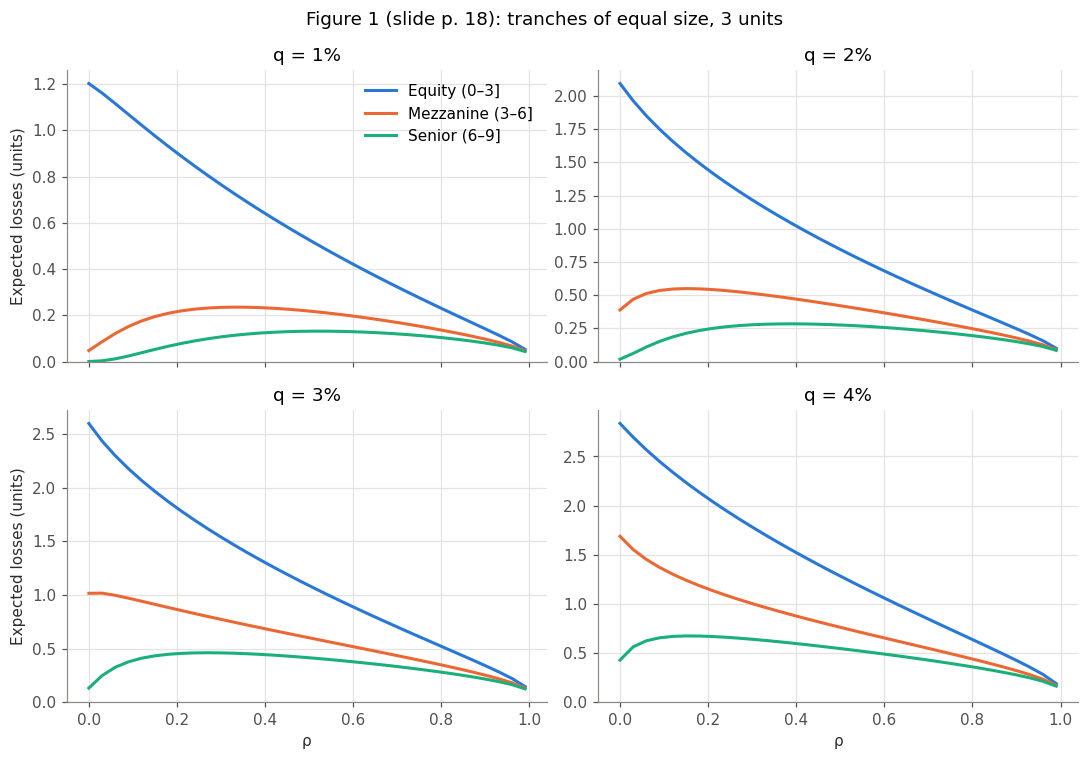

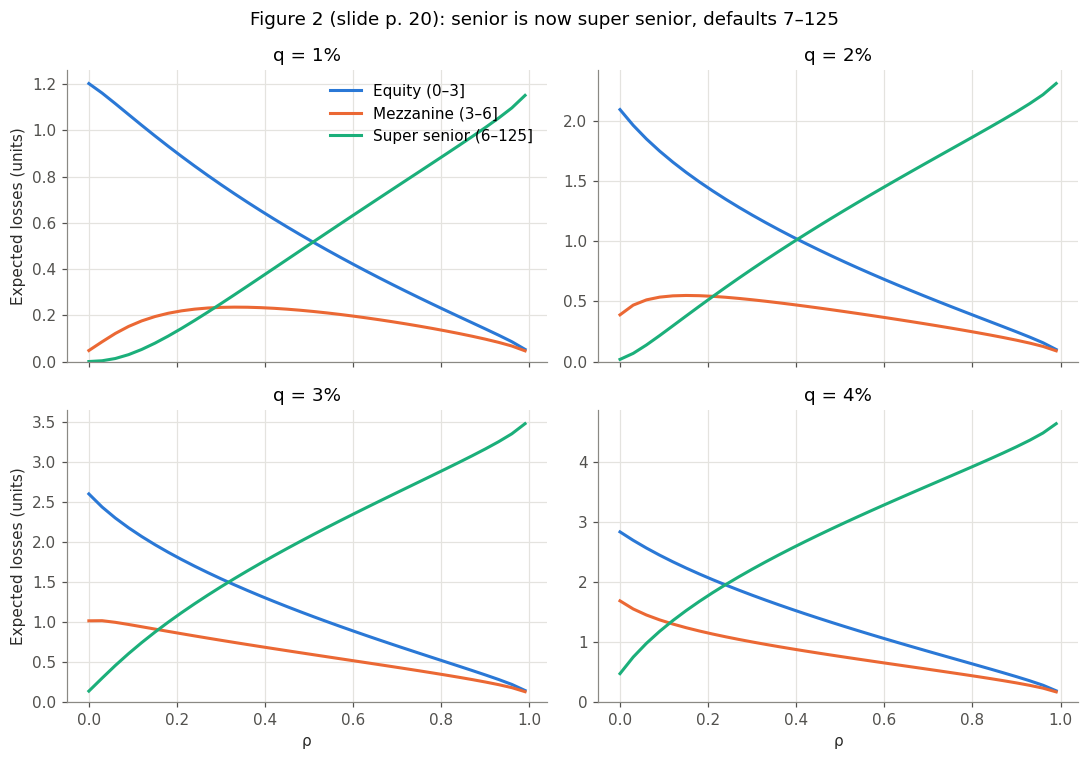

In [11]:
RHO_GRID = np.round(np.arange(0, 1.0, 0.03), 2)
RHO_GRID[-1] = 0.99
Q_LIST = [0.01, 0.02, 0.03, 0.04]

def tranche_curves(q, senior_U):
    out = {k: [] for k in ("Equity", "Mezzanine", "Senior", "Index")}
    for rho in RHO_GRID:
        p = loss_distribution_homog(125, q, rho)
        out["Equity"].append(expected_tranche_loss_units(p, 0, 3))
        out["Mezzanine"].append(expected_tranche_loss_units(p, 3, 6))
        out["Senior"].append(expected_tranche_loss_units(p, 6, senior_U))
        out["Index"].append(expected_tranche_loss_units(p, 0, 125))
    return {k: np.array(v) for k, v in out.items()}

curves_fig1 = {q: tranche_curves(q, 9) for q in Q_LIST}
curves_fig2 = {q: tranche_curves(q, 125) for q in Q_LIST}

def four_panel(curves, title, senior_label):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    for ax, q in zip(axes.ravel(), Q_LIST):
        c = curves[q]
        ax.plot(RHO_GRID, c["Equity"], color=COL["equity"], label="Equity (0–3]")
        ax.plot(RHO_GRID, c["Mezzanine"], color=COL["mezz"], label="Mezzanine (3–6]")
        ax.plot(RHO_GRID, c["Senior"], color=COL["senior"], label=senior_label)
        ax.set_title(f"q = {q:.0%}")
        ax.set_ylim(bottom=0)
    for ax in axes[1]: ax.set_xlabel("ρ")
    for ax in axes[:, 0]: ax.set_ylabel("Expected losses (units)")
    axes[0, 0].legend(loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

four_panel(curves_fig1, "Figure 1 (slide p. 18): tranches of equal size, 3 units", "Senior (6–9]")
four_panel(curves_fig2, "Figure 2 (slide p. 20): senior is now super senior, defaults 7–125", "Super senior (6–125]")

### "Some Important Observations" (p. 19) — verified numerically

1. $\mathbb{E}[\text{Equity}] \ge \mathbb{E}[\text{Mezzanine}] \ge \mathbb{E}[\text{Senior}]$ for **every** $q$ and
   $\rho$ — but only because each tranche has the **same notional** (3 units).
2. Expected equity loss is always **decreasing** in $\rho$.
3. Mezzanine is relatively **insensitive** to $\rho$ (and not monotone) → this makes **calibration** hard (§7).
4. Super-senior (upper attachment $100\%$) expected loss is always **increasing** in $\rho$.
5. The total expected loss across the tranches — the expected loss on the **index** — is **independent of
   $\rho$**. *"This is not an accident!"* By linearity, $\mathbb{E}[l] = \sum_i q_i = Nq$, whatever the dependence.

In [12]:
checks = []
for q in Q_LIST:
    c1, c2 = curves_fig1[q], curves_fig2[q]
    checks.append({
        "q": f"{q:.0%}",
        "1. E ≥ M ≥ S": bool(np.all(c1["Equity"] >= c1["Mezzanine"] - 1e-12) and np.all(c1["Mezzanine"] >= c1["Senior"] - 1e-12)),
        "2. equity ↓ in ρ": bool(np.all(np.diff(c1["Equity"]) < 0)),
        "3. mezz range over ρ": f"{c1['Mezzanine'].min():.2f} – {c1['Mezzanine'].max():.2f}",
        "4. super senior ↑ in ρ": bool(np.all(np.diff(c2["Senior"]) > 0)),
        "5. index = Nq for all ρ": bool(np.allclose(c1["Index"], 125 * q)),
        "E+M+S(7–125) = Nq": bool(np.allclose(c2["Equity"] + c2["Mezzanine"] + c2["Senior"], 125 * q)),
    })
display(pd.DataFrame(checks).style.hide(axis="index"))

q,1. E ≥ M ≥ S,2. equity ↓ in ρ,3. mezz range over ρ,4. super senior ↑ in ρ,5. index = Nq for all ρ,E+M+S(7–125) = Nq
1%,True,True,0.05 – 0.24,True,True,True
2%,True,True,0.09 – 0.55,True,True,True
3%,True,True,0.13 – 1.02,True,True,True
4%,True,True,0.17 – 1.69,True,True,True


---
## 6. The mechanics of a "synthetic" CDO tranche (slides p. 22–24)

* $N$ credits, each with the **same** notional $A$ and recovery $R$, so each default costs $A(1-R)$.
* A tranche is defined by lower and upper attachment points $L$ and $U$ (in % of portfolio notional).
* The **tranche loss function** at time $t$, given $l$ defaults by $t$:

$$
\text{TL}^{L,U}_t(l) := \max\big\lbrace \min\lbrace l\,A(1-R),\ U\rbrace - L,\ 0\big\rbrace .
$$

**Slide example.** $L = 3\%$, $U = 7\%$, portfolio loss $l A(1-R) = 5\%$ → tranche loss $= 2\%$ of
portfolio notional $= 50\%$ of the tranche notional ($U - L = 4\%$).

**Protection seller / buyer.** The protection **seller** reimburses realized tranche losses; the
**buyer** pays a periodic (typically quarterly) premium, sometimes plus an **upfront** payment (common
for equity tranches). The fair premium makes the two legs equal in value, so — like a swap — the
contract is worth zero at inception.

The **expected tranche loss** at time $t$:

$$
\mathbb{E}^{\mathbb{Q}}_0\big[\text{TL}^{L,U}_t\big] = \sum_{l=0}^{N} \text{TL}^{L,U}_t(l)\; p(l,t),
\qquad p(l,t) = \int_{-\infty}^{\infty} p^N(l,t\mid M)\,\phi(M)\,dM .
$$

**Default-time model.** We need $q(t)$ at every payment date. With a constant **hazard rate** $\lambda$
(see the defaultable-bond/CDS lecture), $q(t) = 1 - e^{-\lambda t}$, and the credit-triangle
approximation links $\lambda$ to the CDS / index spread $s$: $\lambda \approx s / (1-R)$.

In [13]:
def TL(l, L, U, N=125, A=None, R=0.40):
    # Slide tranche loss function in % of portfolio notional; A defaults to 1/N (notional normalised to 1).
    A = 1.0 / N if A is None else A
    return np.maximum(np.minimum(l * A * (1 - R), U) - L, 0.0)

# Slide example: L=3%, U=7%, portfolio loss 5%
l_needed = 0.05 / ((1 / 125) * (1 - 0.40))          # number of defaults giving a 5% loss
tl = TL(l_needed, 0.03, 0.07)
print(f"defaults needed for a 5% loss: {l_needed:.3f}")
print(f"tranche loss = {tl:.2%} of portfolio = {tl/0.04:.0%} of the tranche notional")

defaults needed for a 5% loss: 10.417
tranche loss = 2.00% of portfolio = 50% of the tranche notional


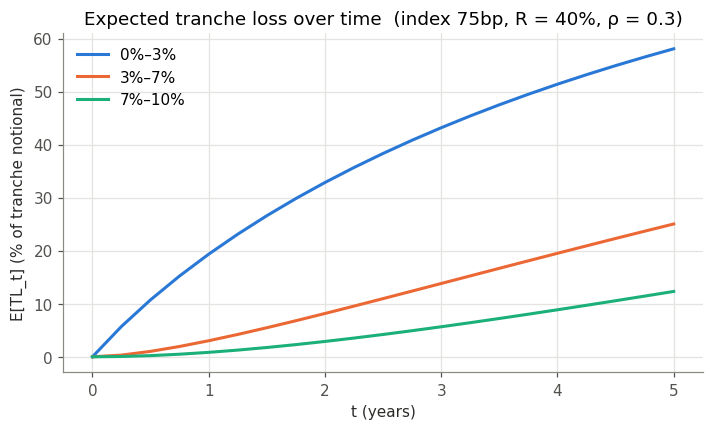

In [14]:
def expected_TL(t, lam, rho, L, U, N=125, R=0.40):
    # E_0[TL_t^{L,U}] in % of portfolio notional, homogeneous pool with hazard rate lam.
    if t <= 0:
        return 0.0
    q_t = 1 - math.exp(-lam * t)
    p = loss_distribution_homog(N, q_t, rho)
    return TL(np.arange(N + 1), L, U, N=N, R=R) @ p

index_spread, R = 0.0075, 0.40
lam_ig = index_spread / (1 - R)
times = np.arange(0, 5.01, 0.25)
tranches_cdx = [(0.00, 0.03), (0.03, 0.07), (0.07, 0.10), (0.10, 0.15), (0.15, 0.30)]

fig, ax = plt.subplots(figsize=(7.5, 4))
for (L, U), c in zip(tranches_cdx[:3], [COL["equity"], COL["mezz"], COL["senior"]]):
    y = [expected_TL(t, lam_ig, 0.30, L, U) / (U - L) for t in times]
    ax.plot(times, np.array(y) * 100, color=c, label=f"{L:.0%}–{U:.0%}")
ax.set(xlabel="t (years)", ylabel="E[TL_t] (% of tranche notional)",
       title="Expected tranche loss over time  (index 75bp, R = 40%, ρ = 0.3)")
ax.legend()
plt.show()

---
## 7. Computing the fair value of a CDO tranche (slides p. 26–28)

Payments on dates $t = 1,\dots,n$ with accrual factor $\Delta_t$ (e.g. $1/4$ for quarterly) and
risk-free discount factors $d_t$.

### Premium leg (p. 26)

Premium is paid on the **remaining** tranche notional — unlike a CDS, the contract does not stop at
the first default:

$$
\text{PL}^{L,U}_0 = S \sum_{t=1}^{n} d_t\,\Delta_t\Big[(U-L) - \mathbb{E}^{\mathbb{Q}}_0\big[\text{TL}^{L,U}_{t-1}\big]\Big]. \tag{6}
$$

### Default leg (p. 27)

The protection buyer receives the **increase** in tranche loss each period:

$$
\text{DL}^{L,U}_0 = \sum_{t=1}^{n} d_t\Big(\mathbb{E}^{\mathbb{Q}}_0\big[\text{TL}^{L,U}_{t}\big] - \mathbb{E}^{\mathbb{Q}}_0\big[\text{TL}^{L,U}_{t-1}\big]\Big). \tag{7}
$$

### Fair spread (p. 28)

$$
S^* = \frac{\text{DL}^{L,U}_0}{\sum_{t=1}^{n} d_t\,\Delta_t\Big[(U-L) - \mathbb{E}^{\mathbb{Q}}_0\big[\text{TL}^{L,U}_{t-1}\big]\Big]} . \tag{8}
$$

The denominator is the **risky PV01** (RPV01): the value of paying 1 per year of running premium.

In [15]:
def tranche_legs(lam, rho, L, U, T, r=0.03, dt=0.25, N=125, R=0.40):
    # Returns (default leg, RPV01) in % of portfolio notional -- slide eqs (6)-(7).
    t = np.arange(0, T + 1e-9, dt)
    etl = np.array([expected_TL(s, lam, rho, L, U, N, R) for s in t])
    d = np.exp(-r * t[1:])
    rpv01 = np.sum(d * dt * ((U - L) - etl[:-1]))
    dl = np.sum(d * (etl[1:] - etl[:-1]))
    return dl, rpv01

def fair_spread(lam, rho, L, U, T=5, **kw):
    dl, rpv01 = tranche_legs(lam, rho, L, U, T, **kw)
    return dl / rpv01                                              # eq (8)

rho_cols = [0.05, 0.15, 0.30, 0.50, 0.70]
tab = pd.DataFrame({f"ρ={r}": [1e4 * fair_spread(lam_ig, r, L, U) for (L, U) in tranches_cdx + [(0, 1)]]
                    for r in rho_cols},
                   index=[f"{L:.0%}–{U:.0%}" for L, U in tranches_cdx] + ["Index 0–100%"])
print("Fair running spreads S* (bp), 5y, quarterly, index 75bp, R = 40%, r = 3%")
display(tab.style.format("{:,.1f}"))

Fair running spreads S* (bp), 5y, quarterly, index 75bp, R = 40%, r = 3%


,ρ=0.05,ρ=0.15,ρ=0.3,ρ=0.5,ρ=0.7
0%–3%,"3,206.5","2,459.7","1,769.6","1,172.5",742.0
3%–7%,534.2,577.5,554.7,480.9,384.9
7%–10%,59.7,172.9,253.5,283.3,268.3
10%–15%,4.8,50.8,121.9,177.3,196.8
15%–30%,0.0,4.1,26.6,68.2,106.2
Index 0–100%,74.0,74.0,74.0,74.0,74.0


**What to notice.**

* The **index** (0–100%) spread is the same for every $\rho$ (≈ the 75bp input, up to the
  credit-triangle approximation) — same reason as Observation 5.
* Equity spread **falls** with $\rho$; senior spreads **rise**; the 3–7% mezzanine first rises, then falls.

### Upfront quotes for the equity tranche

Equity tranches usually trade as an **upfront** payment $u$ (% of tranche notional) plus a fixed
running spread (historically 500bp). The fair upfront equates the legs:

$$
u\,(U-L) + S_{\text{run}}\cdot \text{RPV01} = \text{DL}
\quad\Longrightarrow\quad
u = \frac{\text{DL} - S_{\text{run}}\,\text{RPV01}}{U-L}.
$$

In [16]:
for rho in [0.05, 0.15, 0.30, 0.50]:
    dl, rpv = tranche_legs(lam_ig, rho, 0.0, 0.03, 5)
    upfront = (dl - 0.05 * rpv) / 0.03
    print(f"ρ = {rho:.2f}:  0–3% equity  =  {upfront:6.2%} upfront + 500bp running   (all-running S* = {1e4*dl/rpv:,.0f}bp)")

ρ = 0.05:  0–3% equity  =  66.12% upfront + 500bp running   (all-running S* = 3,206bp)
ρ = 0.15:  0–3% equity  =  53.54% upfront + 500bp running   (all-running S* = 2,460bp)
ρ = 0.30:  0–3% equity  =  39.18% upfront + 500bp running   (all-running S* = 1,770bp)
ρ = 0.50:  0–3% equity  =  23.45% upfront + 500bp running   (all-running S* = 1,172bp)


### Implied correlation — and why it fails (p. 28)

In practice $S^*$ was **observed in the market** and (8) was inverted for an **implied correlation**
$\rho_{\text{impl}}$ (the *compound* correlation), just like implied volatility. Two problems
(both on the slide):

1. A **different** correlation is implied by each tranche (a "correlation smile") — so the model is
   not consistent with the market.
2. For the mezzanine tranche $S^*(\rho)$ is **not monotone**, so a quote may give **two** solutions —
   or **none** at all.

To see this we generate "market" quotes from a model the Gaussian copula does *not* nest
(a 50/50 mixture of a low-$\rho$ and a high-$\rho$ world, which fattens both tails) and back out
$\rho_{\text{impl}}$ tranche by tranche.

In [17]:
def market_spread(L, U, T=5, rhos=(0.05, 0.60), w=(0.5, 0.5)):
    # 'Market' quote: legs averaged over a mixture of correlation regimes.
    legs = [tranche_legs(lam_ig, r, L, U, T) for r in rhos]
    dl = sum(wi * x[0] for wi, x in zip(w, legs))
    rpv = sum(wi * x[1] for wi, x in zip(w, legs))
    return dl / rpv

def implied_correlations(target, L, U, grid=np.linspace(0.01, 0.95, 48)):
    # All roots of S*(rho) = target found by scanning for sign changes, then brentq.
    f = lambda r: fair_spread(lam_ig, r, L, U) - target
    vals = np.array([f(r) for r in grid])
    roots = [brentq(f, grid[k], grid[k + 1]) for k in np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]]
    return roots, grid, vals + target

rows, curves = [], {}
for (L, U) in tranches_cdx:
    s_mkt = market_spread(L, U)
    roots, grid, s_curve = implied_correlations(s_mkt, L, U)
    curves[(L, U)] = (grid, s_curve, s_mkt)
    rows.append({"tranche": f"{L:.0%}–{U:.0%}", "market S* (bp)": 1e4 * s_mkt,
                 "implied ρ": ", ".join(f"{r:.3f}" for r in roots) if roots else "NO SOLUTION"})
display(pd.DataFrame(rows).style.format({"market S* (bp)": "{:,.1f}"}).hide(axis="index"))

tranche,market S* (bp),implied ρ
0%–3%,"1,847.8",0.279
3%–7%,485.5,"0.018, 0.489"
7%–10%,166.9,0.143
10%–15%,96.1,0.239
15%–30%,43.7,0.384


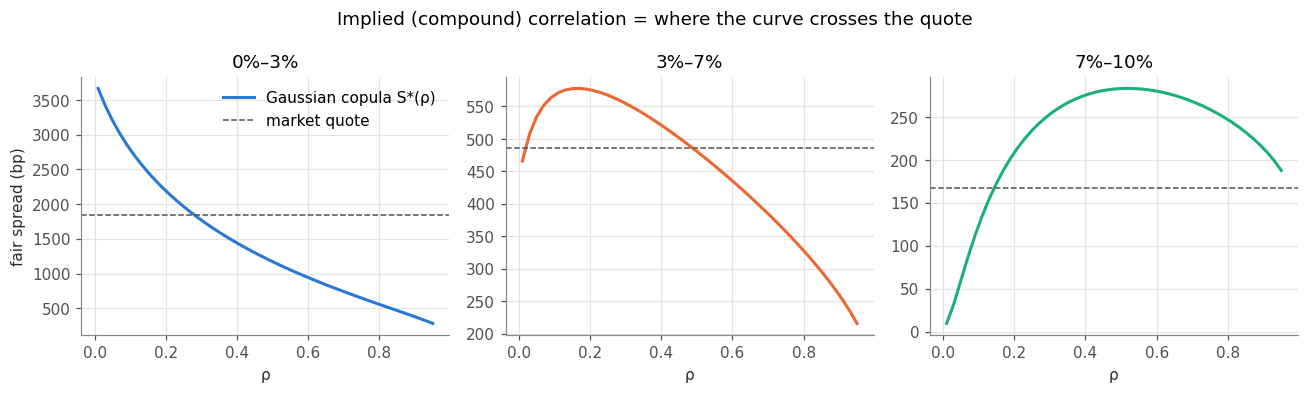

3–7% quote of 607bp (above the model maximum 578bp): implied ρ = NO SOLUTION


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (L, U), c in zip(axes, tranches_cdx[:3], [COL["equity"], COL["mezz"], COL["senior"]]):
    grid, s_curve, s_mkt = curves[(L, U)]
    ax.plot(grid, s_curve * 1e4, color=c, label="Gaussian copula S*(ρ)")
    ax.axhline(s_mkt * 1e4, color=COL["ink"], lw=1, ls="--", label="market quote")
    ax.set(title=f"{L:.0%}–{U:.0%}", xlabel="ρ")
axes[0].set_ylabel("fair spread (bp)")
axes[0].legend()
fig.suptitle("Implied (compound) correlation = where the curve crosses the quote")
fig.tight_layout()
plt.show()

# make a mezzanine quote the model can never hit
s_max = curves[(0.03, 0.07)][1].max()
roots, *_ = implied_correlations(s_max * 1.05, 0.03, 0.07)
print(f"3–7% quote of {1e4*s_max*1.05:,.0f}bp (above the model maximum {1e4*s_max:,.0f}bp): implied ρ = {roots or 'NO SOLUTION'}")

---
## 8. Cash and synthetic CDOs (slides p. 30–32)

| | **Cash CDO** | **Synthetic CDO** |
|---|---|---|
| Reference portfolio | Real corporate bonds/loans held (usually on the issuer's balance sheet) | **Fictitious** portfolio of credits + notionals, referenced through CDSs |
| Why it existed | Reduce **regulatory capital**: sell most tranches, keep the equity → keep most of the economic risk while setting aside far less capital (**regulatory arbitrage**) | Demand: hedge funds bought risky tranches, insurers wanted AAA senior / super-senior |
| Must tranche the whole deal? | Yes — the whole capital structure must be sold | **No** — a bank can sell protection on just a 3–7% tranche |
| Management | Managed; long legal documents; waterfalls, credit enhancement; rated by agencies | No physical bonds, so the dealer is **unhedged** |
| Hedging | Hedged by owning the bonds | Must be **dynamically hedged**, usually with **CDSs / the index** |

### Hedging a synthetic tranche: the credit delta

If a dealer sells protection on one tranche, they hedge the **spread risk** by buying protection on
the index. The hedge ratio (**credit delta**) is the index notional per unit of tranche notional
that makes the position insensitive to a small parallel move in spreads:

$$
\Delta^{L,U} = \frac{\partial V^{L,U} / \partial s}{\partial V^{\text{index}} / \partial s},
\qquad V = \text{DL} - S_{\text{contract}}\cdot\text{RPV01}\ \ (\text{protection buyer's value}).
$$

We compute it with a 1bp bump of the index spread, keeping $\rho$ fixed.

In [19]:
def tranche_value(lam, rho, L, U, S_contract, T=5, **kw):
    # Protection-buyer MTM per unit of TRANCHE notional
    dl, rpv = tranche_legs(lam, rho, L, U, T, **kw)
    return (dl - S_contract * rpv) / (U - L)

def credit_delta(L, U, rho, spread=index_spread, T=5, bump=1e-4, R=0.40):
    lam0, lam1 = spread / (1 - R), (spread + bump) / (1 - R)
    S_tr, S_ix = fair_spread(lam0, rho, L, U, T), fair_spread(lam0, rho, 0, 1, T)
    dV_tr = tranche_value(lam1, rho, L, U, S_tr, T) - tranche_value(lam0, rho, L, U, S_tr, T)
    dV_ix = tranche_value(lam1, rho, 0, 1, S_ix, T) - tranche_value(lam0, rho, 0, 1, S_ix, T)
    return dV_tr / dV_ix, dV_tr

rows = []
for (L, U) in tranches_cdx:
    dlt, dv = credit_delta(L, U, 0.30)
    rows.append({"tranche": f"{L:.0%}–{U:.0%}", "credit delta (x index)": dlt,
                 "value change per 1bp, $ per $10m tranche": dv * 10e6})
display(pd.DataFrame(rows).style.format({"credit delta (x index)": "{:.2f}",
        "value change per 1bp, $ per $10m tranche": "{:,.0f}"}).hide(axis="index"))
print("Equity is many times more spread-sensitive than the index: the leverage of a thin first-loss piece.")

tranche,credit delta (x index),"value change per 1bp, $ per $10m tranche"
0%–3%,13.96,"61,793"
3%–7%,8.50,"37,643"
7%–10%,5.13,"22,688"
10%–15%,2.94,"13,027"
15%–30%,0.81,"3,578"


Equity is many times more spread-sensitive than the index: the leverage of a thin first-loss piece.


The hedge is only as good as the model: the delta depends on the (unobservable) $\rho$, it ignores
**idiosyncratic** moves of single names, and it must be re-balanced as spreads move — "there are
simply too many moving parts" (p. 32). §9 shows what happens when $\rho$ itself moves.

---
## 9. Pricing and risk management of CDO portfolios (slides p. 34–36)

### The sample synthetic CDO portfolio (p. 34)

Positive notional = **sold** protection (long credit risk); negative = **bought** protection.

In [20]:
book = pd.DataFrame([
    ("CDX IG A",  "Equity",    0.00, 0.03, 10, 100,  722),
    ("CDX IG A",  "Mezzanine", 0.03, 0.07,  7, -300, 223),
    ("CDX IG B",  "Senior",    0.07, 0.10,  5, -400,  85),
    ("CDX IG B",  "Equity",    0.00, 0.03,  5,  50,  567),
    ("CDX IG B",  "Index",     0.00, 1.00,  5, -400,  75),
    ("CDX XO D",  "Mezzanine", 0.05, 0.10,  3, -30,  324),
    ("CDX XO E",  "Mezzanine", 0.05, 0.10,  4,  45,   63),
    ("CDX HY F",  "Equity",    0.00, 0.10, 10,  20, 1400),
    ("CDX HY F",  "Mezzanine", 0.10, 0.20, 10, -80,  250),
], columns=["Index", "Tranche", "L", "U", "Maturity", "Notional ($m)", "Price (bp)"])
display(book.style.format({"L": "{:.0%}", "U": "{:.0%}"}).hide(axis="index"))

Index,Tranche,L,U,Maturity,Notional ($m),Price (bp)
CDX IG A,Equity,0%,3%,10,100,722
CDX IG A,Mezzanine,3%,7%,7,-300,223
CDX IG B,Senior,7%,10%,5,-400,85
CDX IG B,Equity,0%,3%,5,50,567
CDX IG B,Index,0%,100%,5,-400,75
CDX XO D,Mezzanine,5%,10%,3,-30,324
CDX XO E,Mezzanine,5%,10%,4,45,63
CDX HY F,Equity,0%,10%,10,20,1400
CDX HY F,Mezzanine,10%,20%,10,-80,250


In practice such books contain many positions on **different reference portfolios, maturities,
counterparties** and **formats** (upfront and/or running). The payoff is very **path dependent**
with large **idiosyncratic** risk, unwinding is expensive (wide bid-offer), and marks can be opaque
(the 2012 "London Whale" was noticed because CDX IG9 levels diverged from related prices).

**Marking the book to market.** The deck gives tranche prices but not the index spreads or the
correlations, so we make explicit, *illustrative* assumptions:

* Index spreads: IG 75bp (the CDX IG B index quote), XO 250bp, HY 450bp; $R = 40\%$; $r = 3\%$.
* Every quote is treated as a running spread and taken as the position's **contract** spread.
* Each tranche is marked with its own **implied correlation** $\rho_{\text{impl}}$ — the $\rho$ that
  reprices its quote (§7). When there are two roots we keep the one closest to $0.25$; when there is
  **no** root we use the closest $\rho$ and the position carries a model MTM.

The protection **seller's** MTM per unit of tranche notional is
$(S_{\text{contract}}\cdot\text{RPV01} - \text{DL})/(U-L)$; positive notional = seller.

In [21]:
INDEX_SPREAD = {"CDX IG": 0.0075, "CDX XO": 0.0250, "CDX HY": 0.0450}

def pos_legs(row, rho, spread_mult=1.0, R=0.40):
    s = INDEX_SPREAD[row.Index[:6]] * spread_mult
    return tranche_legs(s / (1 - R), rho, row.L, row.U, row.Maturity, R=R)

def pos_spread(row, rho, spread_mult=1.0):
    dl, rpv = pos_legs(row, rho, spread_mult)
    return dl / rpv

def calibrate_position(row, base=0.25, grid=np.linspace(0.02, 0.95, 32)):
    if row.U - row.L >= 1:
        return base, "index: price does not depend on ρ"
    quote = row["Price (bp)"] / 1e4
    vals = np.array([pos_spread(row, r) for r in grid]) - quote
    idx = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
    if len(idx) == 0:
        return grid[np.argmin(np.abs(vals))], "NO SOLUTION — closest ρ used"
    roots = [brentq(lambda r: pos_spread(row, r) - quote, grid[k], grid[k + 1]) for k in idx]
    note = "unique" if len(roots) == 1 else "roots: " + ", ".join(f"{r:.3f}" for r in roots)
    return min(roots, key=lambda r: abs(r - base)), note

calib = [calibrate_position(r) for _, r in book.iterrows()]
book["rho_impl"] = [c[0] for c in calib]

def position_mtm(row, spread_mult=1.0, rho_shift=0.0, rho_flat=None):
    rho = rho_flat if rho_flat is not None else float(np.clip(row.rho_impl + rho_shift, 0.01, 0.97))
    dl, rpv = pos_legs(row, rho, spread_mult)
    return row["Notional ($m)"] * (row["Price (bp)"] / 1e4 * rpv - dl) / (row.U - row.L)

def mark_book(spread_mult=1.0, rho_shift=0.0, rho_flat=None):
    return np.array([position_mtm(r, spread_mult, rho_shift, rho_flat) for _, r in book.iterrows()])

mtm0 = mark_book()
marked = book.assign(**{"calibration": [c[1] for c in calib],
                        "model S* (bp)": [1e4 * pos_spread(r, r.rho_impl) for _, r in book.iterrows()],
                        "MTM ($m)": mtm0})
display(marked.style.format({"L": "{:.0%}", "U": "{:.0%}", "rho_impl": "{:.3f}", "model S* (bp)": "{:,.0f}",
                             "MTM ($m)": "{:,.2f}"}).hide(axis="index"))
flat = mark_book(rho_flat=0.25).sum()
print(f"Book MTM at implied correlations     = ${mtm0.sum():,.2f}m")
print(f"Book MTM with one flat ρ = 0.25       = ${flat:,.2f}m   <- same quotes, different model choice")

Index,Tranche,L,U,Maturity,Notional ($m),Price (bp),rho_impl,calibration,model S* (bp),MTM ($m)
CDX IG A,Equity,0%,3%,10,100,722,0.660,unique,722,0.00
CDX IG A,Mezzanine,3%,7%,7,-300,223,0.937,unique,223,0.00
CDX IG B,Senior,7%,10%,5,-400,85,0.068,unique,85,0.00
CDX IG B,Equity,0%,3%,5,50,567,0.795,unique,567,0.00
CDX IG B,Index,0%,100%,5,-400,75,0.250,index: price does not depend on ρ,74,-0.18
CDX XO D,Mezzanine,5%,10%,3,-30,324,0.950,NO SOLUTION — closest ρ used,621,2.34
CDX XO E,Mezzanine,5%,10%,4,45,63,0.950,NO SOLUTION — closest ρ used,611,-8.26
CDX HY F,Equity,0%,10%,10,20,1400,0.869,unique,"1,400",-0.00
CDX HY F,Mezzanine,10%,20%,10,-80,250,0.950,NO SOLUTION — closest ρ used,889,29.90


Book MTM at implied correlations     = $23.80m
Book MTM with one flat ρ = 0.25       = $52.88m   <- same quotes, different model choice


**What the mark tells us.**

* Tranches on the **same** index (CDX IG) imply very different correlations, from below $0.1$ for the
  7–10% senior to above $0.9$ for the 3–7% mezzanine. This is the correlation smile of §7: one
  Gaussian copula cannot price every tranche at once.
* Three mezzanine quotes have **no** implied correlation in this model, so they cannot be marked
  without a model MTM. That MTM is a modelling artefact, not a market value.
* Marking the same quotes with one flat $\rho$ gives a completely different book value. With opaque
  prices, the mark-to-market is largely a **model choice**.

### Greeks (p. 36, point 2)

* **CS01** — P&L for a +1bp move in all index spreads.
* **Corr01** — P&L for a +1 point ($+0.01$) move in correlation.

Greeks are **model dependent** and **local**: they describe small moves only.

In [22]:
mtm_cs = mark_book(spread_mult=1 + 1e-4 / 0.0075)        # +1bp on IG (proportional on XO/HY)
mtm_rho = mark_book(rho_shift=0.01)                       # every implied ρ +0.01
greeks = book[["Index", "Tranche", "L", "U", "Notional ($m)"]].assign(
    **{"CS01 ($k)": (mtm_cs - mtm0) * 1e3, "Corr01 ($k)": (mtm_rho - mtm0) * 1e3})
display(greeks.style.format({"L": "{:.0%}", "U": "{:.0%}", "CS01 ($k)": "{:,.1f}", "Corr01 ($k)": "{:,.1f}"})
        .hide(axis="index"))
print(f"Book: CS01 = ${greeks['CS01 ($k)'].sum():,.1f}k   Corr01 = ${greeks['Corr01 ($k)'].sum():,.1f}k")

Index,Tranche,L,U,Notional ($m),CS01 ($k),Corr01 ($k)
CDX IG A,Equity,0%,3%,100,-468.5,"1,081.3"
CDX IG A,Mezzanine,3%,7%,-300,477.1,"-1,604.6"
CDX IG B,Senior,7%,10%,-400,727.3,"2,391.8"
CDX IG B,Equity,0%,3%,50,-121.9,361.0
CDX IG B,Index,0%,100%,-400,177.1,0.0
CDX XO D,Mezzanine,5%,10%,-30,58.3,-174.4
CDX XO E,Mezzanine,5%,10%,45,-102.9,300.8
CDX HY F,Equity,0%,10%,20,-158.0,334.2
CDX HY F,Mezzanine,10%,20%,-80,396.7,-577.6


Book: CS01 = $985.2k   Corr01 = $2,112.4k


### Scenario analysis (p. 36, point 1)

*What are the risk factors? What are reasonable stress levels? How do we revalue?* Here: spreads
$\times\lbrace 0.75, 1, 1.5, 2\rbrace $ and correlation shifts $\lbrace -0.10, 0, +0.10\rbrace $, with **full revaluation**. Compare
the full-revaluation P&L with the linear Greek estimate to see why Greeks "don't work well" for big
moves.

In [23]:
spread_mults, rho_shifts = [0.75, 1.0, 1.5, 2.0], [-0.10, 0.0, 0.10]
grid_pnl = pd.DataFrame(
    [[mark_book(m, d).sum() - mtm0.sum() for m in spread_mults] for d in rho_shifts],
    index=[f"ρ {d:+.2f}" for d in rho_shifts], columns=[f"spreads x{m}" for m in spread_mults])
print("Book P&L under stress, full revaluation ($m)")
display(grid_pnl.style.format("{:,.2f}"))

# Greek (linear) estimate vs full revaluation for spreads x2 (IG +75bp)
cs01_book = (mtm_cs - mtm0).sum()
print(f"Spreads x2: linear CS01 estimate = ${cs01_book * 75:,.2f}m   vs   full revaluation = ${grid_pnl.iloc[1, 3]:,.2f}m")

Book P&L under stress, full revaluation ($m)


,spreads x0.75,spreads x1.0,spreads x1.5,spreads x2.0
ρ -0.10,-22.61,-15.28,19.63,99.30
ρ +0.00,-14.69,0.00,49.48,116.27
ρ +0.10,9.93,30.58,79.89,132.87


Spreads x2: linear CS01 estimate = $73.89m   vs   full revaluation = $116.27m


### Case study: May 2005, Ford and GM downgrades (p. 36)

A popular hedge-fund trade was **sell protection on equity** and **buy delta-hedged protection on
mezzanine** — roughly neutral to parallel spread moves. When Ford and GM were downgraded,
**idiosyncratic** spreads blew out and **implied correlation collapsed**. In the market, equity spreads
widened (the seller lost) *and* mezzanine spreads tightened (the hedge lost too).

We reproduce the mechanism with the **heterogeneous** loss engine of §3: shock 2 of the 125 names
to a 10× spread, and drop $\rho$ from 0.30 to 0.15.

In [24]:
def hetero_legs(lams, a, L, U, T=5, r=0.03, dt=0.25, R=0.40):
    N = len(lams)
    t = np.arange(0, T + 1e-9, dt)
    l = np.arange(N + 1)
    tl = TL(l, L, U, N=N, R=R)
    etl = np.array([0.0] + [tl @ loss_distribution(1 - np.exp(-lams * s), a) for s in t[1:]])
    d = np.exp(-r * t[1:])
    return np.sum(d * (etl[1:] - etl[:-1])), np.sum(d * dt * ((U - L) - etl[:-1]))

N_pool = 125
lam_base = np.full(N_pool, lam_ig)
lam_shock = lam_base.copy(); lam_shock[:2] *= 10          # "Ford" and "GM"

EQ, MZ = (0.00, 0.03), (0.03, 0.07)
S_eq = fair_spread(lam_ig, 0.30, *EQ); S_mz = fair_spread(lam_ig, 0.30, *MZ)
hedge = credit_delta(*EQ, 0.30)[0] / credit_delta(*MZ, 0.30)[0]     # mezz notional per 1 equity, spread-neutral

def trade_pnl(lams, rho, notional_eq=10e6):
    a = np.full(N_pool, math.sqrt(rho))
    dl_e, rpv_e = hetero_legs(lams, a, *EQ)
    dl_m, rpv_m = hetero_legs(lams, a, *MZ)
    seller_eq = (S_eq * rpv_e - dl_e) / 0.03 * notional_eq
    buyer_mz = (dl_m - S_mz * rpv_m) / 0.04 * notional_eq * hedge
    return seller_eq, buyer_mz

base = np.array(trade_pnl(lam_base, 0.30))
rows = []
for name, lams, rho in [("parallel +10bp, ρ unchanged", lam_base * (85 / 75), 0.30),
                        ("2 names x10 spread, ρ unchanged", lam_shock, 0.30),
                        ("2 names x10 spread, ρ 0.30 → 0.15", lam_shock, 0.15)]:
    pnl = np.array(trade_pnl(lams, rho)) - base
    rows.append({"scenario": name, "short equity protection": pnl[0], "long mezz protection": pnl[1], "total": pnl.sum()})
print(f"Trade: sell $10m 0–3% protection, buy ${hedge*10:,.1f}m 3–7% protection (spread-neutral at ρ = 0.30)")
display(pd.DataFrame(rows).style.format({c: "${:,.0f}" for c in ["short equity protection", "long mezz protection", "total"]})
        .hide(axis="index"))

Trade: sell $10m 0–3% protection, buy $16.4m 3–7% protection (spread-neutral at ρ = 0.30)


scenario,short equity protection,long mezz protection,total
"parallel +10bp, ρ unchanged","$-589,338","$609,858","$20,520"
"2 names x10 spread, ρ unchanged","$-857,455","$505,822","$-351,633"
"2 names x10 spread, ρ 0.30 → 0.15","$-2,697,154","$821,295","$-1,875,859"


**Reading the result.**

* A **parallel** move is hedged: the two legs almost cancel.
* An **idiosyncratic** shock already breaks the hedge. Losses concentrated in a few names hit the
  first-loss equity piece much harder than the spread-matched mezzanine.
* Adding the **correlation** drop makes it far worse: equity is very sensitive to $\rho$, while the
  3–7% mezzanine is nearly **insensitive** to $\rho$ (Observation 3, §5), so the hedge does almost
  nothing. In this one-factor Gaussian copula the mezzanine leg even gains a little. In 2005 the market
  moved the mezzanine the other way too, which a single flat $\rho$ cannot capture.

A spread-neutral book can still carry large **correlation** and **idiosyncratic** risk. **Liquidity
risk**, **market endogeneity**, and over-reliance on ratings and models all played a part in the
crisis (p. 36).

---
## 10. A brief aside on copulas (slides p. 37–38)

The Gaussian copula was heavily (and justly) criticised — though nothing in that criticism was new
before the crisis. A common fallacy: **marginal distributions + a correlation matrix determine the joint
distribution.** They do **not** — correlation only measures *linear* dependence.

**Slide counter-example (p. 38).** 5000 draws from a **Bivariate Normal** and from a **Meta-Gumbel**
distribution. Both have **standard normal marginals** and correlation $\approx 0.7$, but the Meta-Gumbel
puts far more mass on **large joint moves**.

**Construction.** A copula $C$ glues marginals together: $(U_1,U_2) \sim C$, then $X_k = \Phi^{-1}(U_k)$.
The Gumbel copula $C_\theta(u_1,u_2) = \exp\!\big(-[(-\ln u_1)^\theta + (-\ln u_2)^\theta]^{1/\theta}\big)$ is
sampled with the Marshall–Olkin algorithm: draw $V \sim$ positive stable with index $1/\theta$ and
$E_k \sim \text{Exp}(1)$, then $U_k = \exp\!\big(-(E_k/V)^{1/\theta}\big)$. Its **upper tail dependence** is
$\lambda_U = 2 - 2^{1/\theta} > 0$, while the Gaussian copula has $\lambda_U = 0$.

We pick $\theta$ so that the Gumbel sample has the same correlation, $0.7$.

θ = 2.009   upper tail dependence λ_U = 0.588
sample correlation: Normal 0.703   Meta-Gumbel 0.706


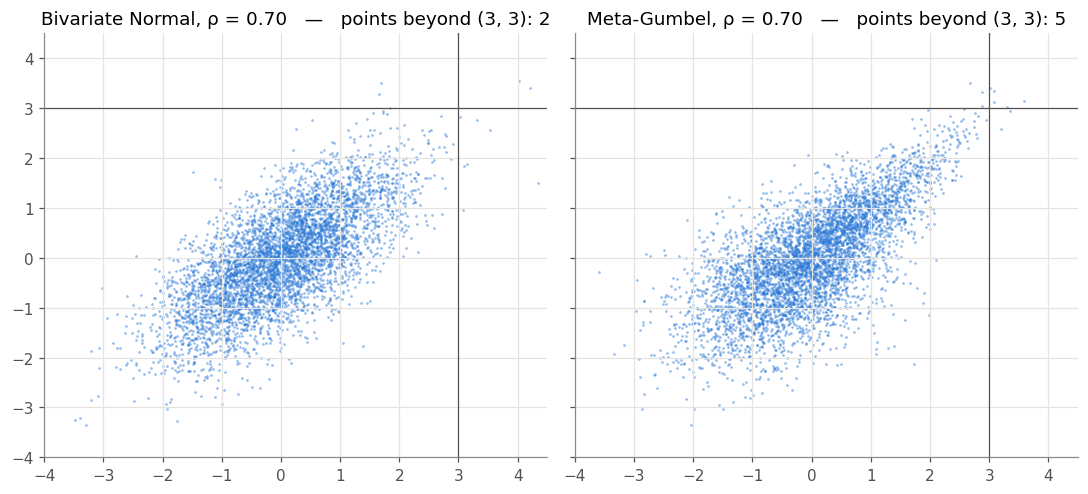

P(X1 > 2, X2 > 2):  Normal 7.36e-03   Meta-Gumbel 1.36e-02
P(X1 > 2.5, X2 > 2.5):  Normal 1.49e-03   Meta-Gumbel 3.75e-03
P(X1 > 3, X2 > 3):  Normal 2.49e-04   Meta-Gumbel 8.20e-04


In [25]:
def positive_stable(alpha, n, rng):
    # Chambers-Mallows-Stuck: Laplace transform E[exp(-sV)] = exp(-s^alpha), 0 < alpha < 1
    U = rng.uniform(0, np.pi, n); E = rng.exponential(1.0, n)
    return (np.sin(alpha * U) / np.sin(U) ** (1 / alpha)) * (np.sin((1 - alpha) * U) / E) ** ((1 - alpha) / alpha)

def meta_gumbel(theta, n, rng):
    V = positive_stable(1 / theta, n, rng)[:, None]
    E = rng.exponential(1.0, (n, 2))
    U = np.exp(-(E / V) ** (1 / theta))
    return norm.ppf(np.clip(U, 1e-15, 1 - 1e-15))

# calibrate theta so that Pearson correlation of the normal-marginal sample is 0.70 (large fixed-seed sample)
f = lambda th: np.corrcoef(meta_gumbel(th, 400_000, np.random.default_rng(7)).T)[0, 1] - 0.70
theta = brentq(f, 1.2, 3.0)

n = 5000
G = rng.multivariate_normal([0, 0], [[1, 0.7], [0.7, 1]], n)
H = meta_gumbel(theta, n, rng)
print(f"θ = {theta:.3f}   upper tail dependence λ_U = {2 - 2**(1/theta):.3f}")
print(f"sample correlation: Normal {np.corrcoef(G.T)[0,1]:.3f}   Meta-Gumbel {np.corrcoef(H.T)[0,1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, Y, title in [(axes[0], G, "Bivariate Normal, ρ = 0.70"), (axes[1], H, "Meta-Gumbel, ρ = 0.70")]:
    ax.scatter(Y[:, 0], Y[:, 1], s=3, color=COL["equity"], alpha=0.5, linewidths=0)
    ax.axvline(3, color=COL["ink"], lw=0.8); ax.axhline(3, color=COL["ink"], lw=0.8)
    ax.set(title=f"{title}   —   points beyond (3, 3): {np.sum((Y[:,0] > 3) & (Y[:,1] > 3))}",
           xlim=(-4, 4.5), ylim=(-4, 4.5))
plt.tight_layout(); plt.show()

big = 2_000_000
Gb = rng.multivariate_normal([0, 0], [[1, 0.7], [0.7, 1]], big); Hb = meta_gumbel(theta, big, rng)
for k in (2, 2.5, 3):
    print(f"P(X1 > {k}, X2 > {k}):  Normal {np.mean((Gb > k).all(1)):.2e}   Meta-Gumbel {np.mean((Hb > k).all(1)):.2e}")

### Why this matters for CDOs

Defaults live in the **lower** tail of the asset values, so for credit the relevant feature is
**lower tail dependence**. The **Clayton** copula has it ($\lambda_L = 2^{-1/\theta}$); the Gaussian does not.
We price the §4 tranches under both, matched on the **same rank correlation** (Kendall's $\tau$):
$\tau_{\text{Gauss}} = \tfrac{2}{\pi}\arcsin\rho$ and $\tau_{\text{Clayton}} = \theta/(\theta+2)$.

Clayton sampling (Marshall–Olkin): $V \sim \text{Gamma}(1/\theta)$, $U_i = (1 + E_i/V)^{-1/\theta}$.

In [26]:
def mc_defaults_gauss(N, q, rho, n, rng):
    M = rng.standard_normal((n, 1))
    X = math.sqrt(rho) * M + math.sqrt(1 - rho) * rng.standard_normal((n, N))
    return (X <= norm.ppf(q)).sum(1)

def mc_defaults_clayton(N, q, theta, n, rng):
    V = rng.gamma(1 / theta, 1.0, (n, 1))
    U = (1 + rng.exponential(1.0, (n, N)) / V) ** (-1 / theta)
    return (U <= q).sum(1)

N, q, rho, n = 125, 0.02, 0.30, 200_000
tau = 2 / np.pi * np.arcsin(rho)
theta_c = 2 * tau / (1 - tau)

l_g = mc_defaults_gauss(N, q, rho, n, rng)
l_c = mc_defaults_clayton(N, q, theta_c, n, rng)
p_exact = loss_distribution_homog(N, q, rho)

rows = []
for name, (L, U) in {**TRANCHES_I, "Super senior": (9, 125)}.items():
    rows.append({"tranche": f"{name} ({L}–{U}]",
                 "Gaussian (semi-analytic)": expected_tranche_loss_units(p_exact, L, U),
                 "Gaussian (MC)": tranche_loss(l_g, L, U).mean(),
                 "Clayton (MC)": tranche_loss(l_c, L, U).mean()})
print(f"Same q = {q:.0%}, same Kendall τ = {tau:.3f} (Gaussian ρ = {rho}, Clayton θ = {theta_c:.3f})")
display(pd.DataFrame(rows).style.format(precision=3).hide(axis="index"))
print(f"E[l]: Gaussian {l_g.mean():.3f}   Clayton {l_c.mean():.3f}   Nq = {N*q:.3f}  (index loss unchanged again)")

Same q = 2%, same Kendall τ = 0.194 (Gaussian ρ = 0.3, Clayton θ = 0.481)


tranche,Gaussian (semi-analytic),Gaussian (MC),Clayton (MC)
Equity (0–3],1.217,1.218,0.549
Mezzanine (3–6],0.514,0.516,0.332
Senior (6–9],0.277,0.277,0.248
Super senior (9–125],0.492,0.498,1.408


E[l]: Gaussian 2.508   Clayton 2.538   Nq = 2.500  (index loss unchanged again)


Same marginals, same rank correlation, same expected index loss — yet the senior tranches carry a
very different expected loss. **The copula is a modelling choice that the market data used to
calibrate it (marginal $q_i$ and one $\rho$) cannot pin down**, and it is exactly the senior tranches
(rated AAA) that are most exposed to that choice.

---
## 11. CDO-squared's and beyond (slides p. 40–45)

Tranching has a genuine **risk-sharing** motivation. But the market then built ever more complex
products that are hard to justify economically and are rich in **product, model and legal risk**.

**Creating a CDO² (p. 43).** Take 100 different CDOs and pool their **mezzanine** tranches (3–7%).
That pool is the collateral of a new CDO — the **CDO²** — which is itself tranched. A mezzanine tranche
now plays the role of a bond. Crucially, **many of the same bonds sit in many of the underlying CDOs**.
Stack once more and you get a **CDO³** (p. 45).

**The joys of CDO² (p. 44).** ≈150 pages of legal contract per underlying tranche → $100 \times 150 =$
**15,000 pages**, plus the CDO² contract itself; thousands of lines of code just to track performance;
and no obvious way to do scenario analysis or VaR/CVaR.

### Simulation

* A universe of 250 names, Gaussian copula with $\rho = 0.30$, 5-year default probability $q$, $R = 40\%$.
* 100 inner CDOs, each referencing **125 names drawn from the same 250** → heavy overlap.
* Each inner CDO's 3–7% mezzanine loss (as % of the mezzanine notional) is one "bond" of the CDO².
* CDO² tranches on the pool of 100 mezzanine tranches: 0–10%, 10–30%, 30–100%.

In [27]:
def simulate_cdo2(q, rho=0.30, n_names=250, n_cdo=100, names_per_cdo=125, n_sims=20_000, R=0.40,
                  mezz=(0.03, 0.07), seed=11):
    g = np.random.default_rng(seed)
    membership = np.zeros((n_cdo, n_names))
    for k in range(n_cdo):
        membership[k, g.choice(n_names, names_per_cdo, replace=False)] = 1.0
    M = g.standard_normal((n_sims, 1))
    X = math.sqrt(rho) * M + math.sqrt(1 - rho) * g.standard_normal((n_sims, n_names))
    D = (X <= norm.ppf(q)).astype(float)                                  # (sims, names)
    cdo_loss = D @ membership.T * (1 - R) / names_per_cdo                 # (sims, CDOs), % of each pool
    mezz_loss = tranche_loss(cdo_loss, *mezz) / (mezz[1] - mezz[0])       # % of each mezz tranche
    pool_loss = mezz_loss.mean(1)                                         # CDO^2 collateral loss
    overlap = (membership @ membership.T)[np.triu_indices(n_cdo, 1)].mean() / names_per_cdo
    return cdo_loss, mezz_loss, pool_loss, overlap

CDO2_TR = {"CDO² equity 0–10%": (0.0, 0.1), "CDO² mezz 10–30%": (0.1, 0.3), "CDO² senior 30–100%": (0.3, 1.0)}
rows = []
for q in [0.01, 0.02, 0.03, 0.05]:
    cdo_loss, mezz_loss, pool_loss, overlap = simulate_cdo2(q)
    r = {"5y q": f"{q:.0%}", "E[inner pool loss]": cdo_loss.mean(), "E[inner mezz loss]": mezz_loss.mean(),
         "P(all 100 mezz wiped out)": np.mean(mezz_loss.min(1) >= 1)}
    for name, (L, U) in CDO2_TR.items():
        r[name] = (tranche_loss(pool_loss, L, U) / (U - L)).mean()
    rows.append(r)
print(f"Average name overlap between two inner CDOs: {overlap:.0%}")
display(pd.DataFrame(rows).style.format({c: "{:.2%}" for c in rows[0] if c != "5y q"}).hide(axis="index"))

Average name overlap between two inner CDOs: 50%


5y q,E[inner pool loss],E[inner mezz loss],P(all 100 mezz wiped out),CDO² equity 0–10%,CDO² mezz 10–30%,CDO² senior 30–100%
1%,0.60%,2.23%,0.34%,5.62%,3.22%,1.46%
2%,1.20%,6.19%,1.15%,13.22%,8.76%,4.45%
3%,1.80%,10.65%,2.27%,20.63%,14.66%,8.08%
5%,3.00%,19.96%,6.09%,34.25%,26.06%,16.18%


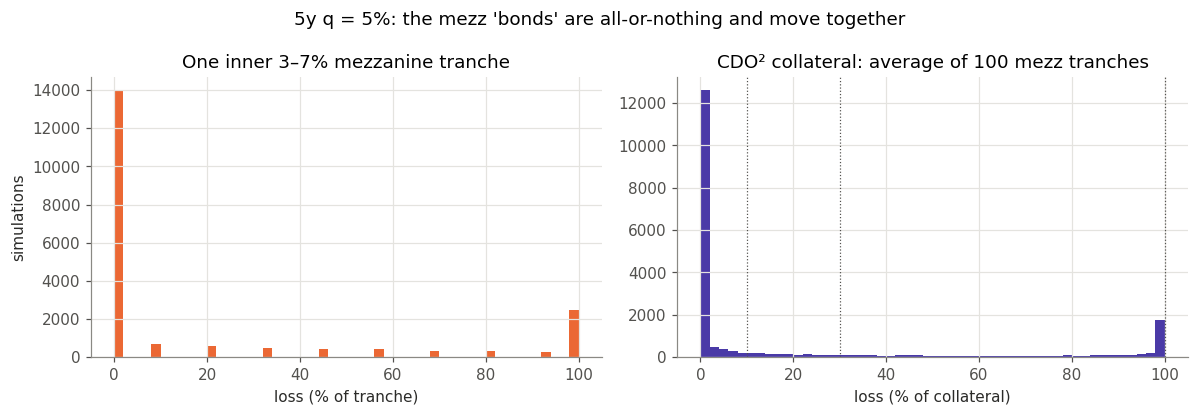

In [28]:
cdo_loss, mezz_loss, pool_loss, _ = simulate_cdo2(0.05)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(mezz_loss[:, 0] * 100, bins=50, color=COL["mezz"])
axes[0].set(title="One inner 3–7% mezzanine tranche", xlabel="loss (% of tranche)", ylabel="simulations")
axes[1].hist(pool_loss * 100, bins=50, color=COL["extra"])
for L, U in CDO2_TR.values():
    axes[1].axvline(U * 100, color=COL["ink"], lw=0.8, ls=":")
axes[1].set(title="CDO² collateral: average of 100 mezz tranches", xlabel="loss (% of collateral)")
fig.suptitle("5y q = 5%: the mezz 'bonds' are all-or-nothing and move together")
fig.tight_layout(); plt.show()

**Takeaways.**

* Each mezzanine "bond" is close to **all-or-nothing** (left histogram). Because the inner CDOs share
  collateral (≈50% overlap here) they are wiped out **together**, so averaging 100 of them gives
  almost no diversification (right histogram: mass at 0% and at 100%).
* The CDO² **senior** 30–100% tranche — the piece that would be sold as "AAA" — has an expected loss
  roughly 2½–5× the expected loss of the **bonds underneath** (compare it with "E[inner pool loss]").
  Tranching twice concentrates the tail rather than removing it.
* Moving $q$ by a percentage point moves the CDO² tranche losses by many points, so small model errors
  in $q$ or $\rho$ become very large pricing errors.
* Scenario analysis or VaR/CVaR needs the joint behaviour of every underlying name across every
  inner deal, and a CDO³ adds one more layer.

---
## 12. Summary — formula cheat-sheet

| Concept | Formula |
|---|---|
| One-factor model | $X_i = a_i M + \sqrt{1-a_i^2}\,Z_i$, $\ \operatorname{Corr}(X_i,X_j)=a_ia_j$ |
| Default threshold | $\bar{x}_i(t) = \Phi^{-1}(q_i(t))$ |
| Conditional default prob. | $q_i(t\mid M) = \Phi\big((\bar{x}_i(t)-a_iM)/\sqrt{1-a_i^2}\big)$ |
| Iterative procedure | $p^{k+1}(l\mid M) = p^k(l\mid M)(1-q_{k+1}(\cdot\mid M)) + p^k(l-1\mid M)\,q_{k+1}(\cdot\mid M)$ |
| Homogeneous case | $p^N(l\mid M) = \binom{N}{l}q_M^l(1-q_M)^{N-l}$, $\ q_M = \Phi\big((\Phi^{-1}(q)-\sqrt\rho M)/\sqrt{1-\rho}\big)$ |
| Unconditional distribution | $p^N(l,t) = \int p^N(l,t\mid M)\,\phi(M)\,dM$ |
| Tranche loss | $\text{TL}^{L,U}_t(l) = \max\lbrace\min\lbrace lA(1-R),U\rbrace - L, 0\rbrace$ |
| Expected tranche loss | $\mathbb{E}^{\mathbb{Q}}_0[\text{TL}^{L,U}_t] = \sum_l \text{TL}^{L,U}_t(l)\,p(l,t)$ |
| Premium leg | $S\sum_t d_t\Delta_t\big[(U-L) - \mathbb{E}[\text{TL}_{t-1}]\big]$ |
| Default leg | $\sum_t d_t\big(\mathbb{E}[\text{TL}_t] - \mathbb{E}[\text{TL}_{t-1}]\big)$ |
| Fair spread | $S^* = \text{DL} \big/ \sum_t d_t\Delta_t\big[(U-L)-\mathbb{E}[\text{TL}_{t-1}]\big]$ |
| Index expected loss | $\mathbb{E}[l] = \sum_i q_i$ — independent of the dependence structure |

### Link to Problem Set 4

The problem set (20 credits, unit notional, zero recovery, **independent** defaults) is the special
case $a_i = 0$ of §3: no integral over $M$ is needed and the iterative procedure runs once. The same
`loss_distribution` function reproduces every answer.

In [29]:
p_ps4 = np.array([.2, .2, .06, .3, .4, .65, .3, .23, .02, .12, .134, .21, .08, .1, .1, .02, .3, .015, .2, .03])
dist = loss_distribution(p_ps4, 0.0)
l = np.arange(len(dist))
EL = l @ dist
print(f"Q1 p^N(3) = {dist[3]:.3f}")
print(f"Q2 E[L]   = {EL:.2f}")
print(f"Q3 Var(L) = {(l**2) @ dist - EL**2:.2f}")
for k, (L, U) in zip((4, 5, 6), [(0, 2), (2, 4), (4, 20)]):
    print(f"Q{k} E[TL {L}-{U}] = {expected_tranche_loss_units(dist, L, U):.2f}")

Q1 p^N(3) = 0.240
Q2 E[L]   = 3.67
Q3 Var(L) = 2.54
Q4 E[TL 0-2] = 1.91
Q5 E[TL 2-4] = 1.28
Q6 E[TL 4-20] = 0.47
